In [1]:
# Load the Qiskit Runtime service
from qiskit_ibm_runtime import QiskitRuntimeService

# Load the Runtime primitive and session
from qiskit_ibm_runtime import EstimatorV2 as Estimator

#All from other notebook
#initialization
import matplotlib.pyplot as plt
import numpy as np
import math

# importing Qiskit
from qiskit_aer import Aer
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile

# import basic plot tools
from qiskit.visualization import plot_histogram, plot_bloch_multivector

backend = Aer.get_backend('qasm_simulator')
print(backend.name)

qasm_simulator


In [2]:
from qiskit.quantum_info import SparsePauliOp
import numpy as np

# Qubit Hamiltonian of the hydrogen atom generated by using STO-3G basis set and parity mapping
Hamiltonian = SparsePauliOp.from_list([("I", -0.2355), ("Z", 0.2355)])

# exact ground state energy of Hamiltonian

A = np.array(Hamiltonian)
eigenvalues, eigenvectors = np.linalg.eig(A)
print(
    "The exact ground state energy of the Hamiltonian is ",
    min(eigenvalues).real,
    "hartree",
)
h = min(eigenvalues.real)

The exact ground state energy of the Hamiltonian is  -0.471 hartree


In [3]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector, DensityMatrix, Pauli

theta = Parameter("θ")
phi = Parameter("φ")
lam = Parameter("λ")

ansatz1 = QuantumCircuit(1)
ansatz1.rx(theta, 0)

ansatz2 = QuantumCircuit(1)
ansatz2.rx(theta, 0)
ansatz2.rz(phi, 0)

ansatz3 = QuantumCircuit(1)
ansatz3.rx(theta, 0)
ansatz3.rz(phi, 0)
ansatz3.rx(lam, 0)

In [4]:
import matplotlib.pyplot as plt


def plot_bloch(bloch_vectors):
    # Extract X, Y, Z coordinates for 3D projection
    X_coords = bloch_vectors[:, 0]
    Z_coords = bloch_vectors[:, 2]

    # Compute Y coordinates from X and Z to approximate the full Bloch sphere projection
    Y_coords = bloch_vectors[:, 1]

    # Create 3D plot
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(X_coords, Y_coords, Z_coords, color="blue", alpha=0.6)

    # Labels and title
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title("Parameterized 1-Qubit Circuit on 3D Bloch Sphere")

    # Set axis limits and make them equal
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])

    # Ensure equal aspect ratio for all axes
    ax.set_box_aspect([1, 1, 1])  # Equal scaling for x, y, z axes

    # Show grid
    ax.grid(True)

    plt.show()


num_samples = 5000  # Number of random states
theta_vals = np.random.uniform(0, 2 * np.pi, num_samples)
phi_vals = np.random.uniform(0, 2 * np.pi, num_samples)
lam_vals = np.random.uniform(0, 2 * np.pi, num_samples)

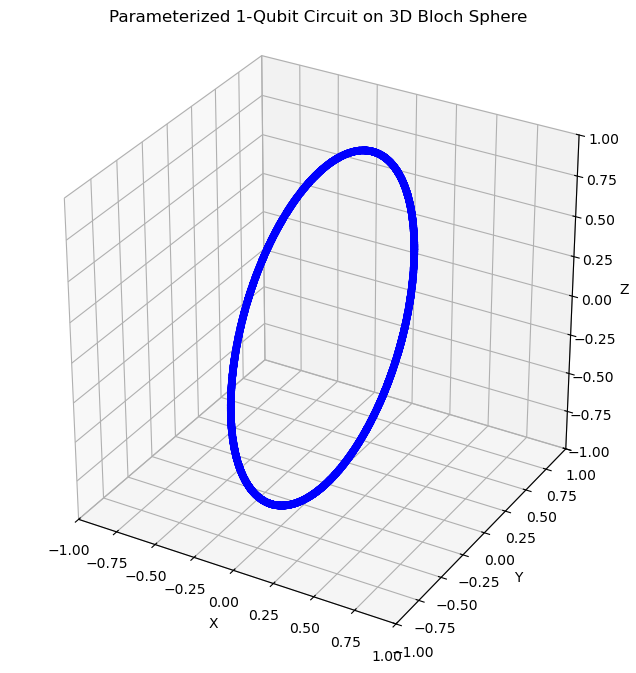

In [5]:
# List to store Bloch Sphere XZ coordinates
bloch_vectors = []

# Generate quantum states and extract Bloch vectors
for i in range(num_samples):
    # Create a circuit and bind parameters
    qc = ansatz1
    bound_qc = qc.assign_parameters({theta: theta_vals[i]})  # , lam: lam_vals[i]})
    state = Statevector.from_instruction(bound_qc)
    rho = DensityMatrix(state)

    X = rho.expectation_value(Pauli("X")).real
    Y = rho.expectation_value(Pauli("Y")).real
    Z = rho.expectation_value(Pauli("Z")).real
    bloch_vectors.append([X, Y, Z])  # Store X, Z components

# Convert to a numpy array for plotting
bloch_vectors = np.array(bloch_vectors)

plot_bloch(bloch_vectors)

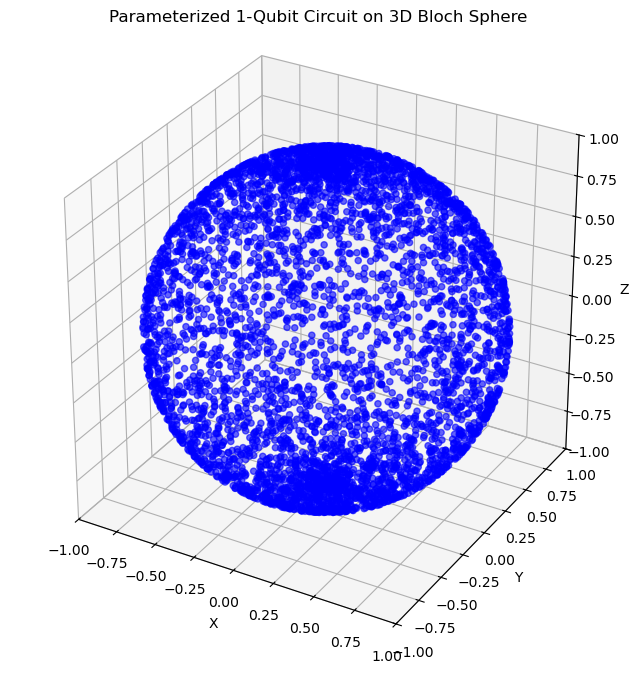

In [6]:
bloch_vectors = []

# Generate quantum states and extract Bloch vectors
for i in range(num_samples):
    # Create circuit and bind parameters
    qc = ansatz2
    bound_qc = qc.assign_parameters(
        {theta: theta_vals[i], phi: phi_vals[i]}
    )  # , lam: lam_vals[i]})
    state = Statevector.from_instruction(bound_qc)
    rho = DensityMatrix(state)

    X = rho.expectation_value(Pauli("X")).real
    Y = rho.expectation_value(Pauli("Y")).real
    Z = rho.expectation_value(Pauli("Z")).real
    bloch_vectors.append([X, Y, Z])  # Store X, Z components

# Convert to numpy array for plotting
bloch_vectors = np.array(bloch_vectors)

plot_bloch(bloch_vectors)

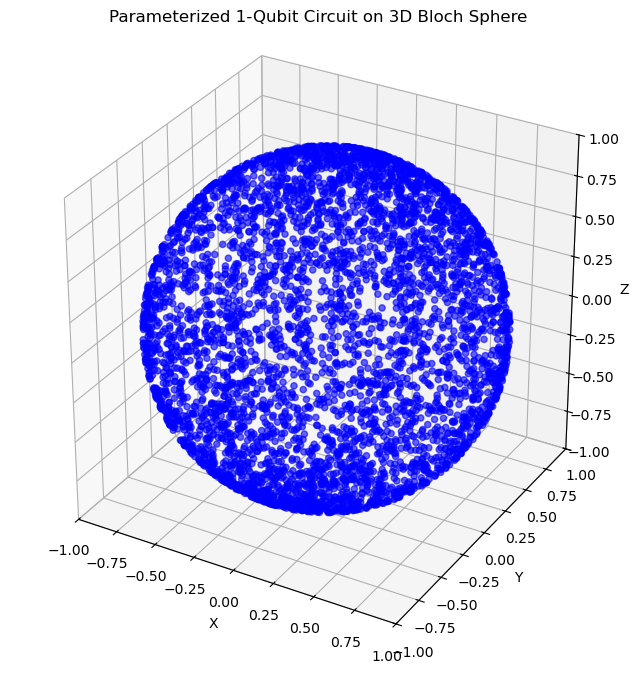

In [7]:
bloch_vectors = []

# Generate quantum states and extract Bloch vectors
for i in range(num_samples):
    # Create circuit and bind parameters
    qc = ansatz3
    bound_qc = qc.assign_parameters(
        {theta: theta_vals[i], phi: phi_vals[i], lam: lam_vals[i]}
    )
    state = Statevector.from_instruction(bound_qc)
    rho = DensityMatrix(state)

    X = rho.expectation_value(Pauli("X")).real
    Y = rho.expectation_value(Pauli("Y")).real
    Z = rho.expectation_value(Pauli("Z")).real
    bloch_vectors.append([X, Y, Z])  # Store X, Z components

# Convert to numpy array for plotting
bloch_vectors = np.array(bloch_vectors)

plot_bloch(bloch_vectors)

This circuit has  3 parameters


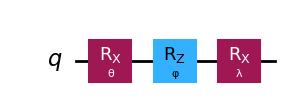

In [8]:
# Pre-defined ansatz circuit and operator class for Hamiltonian

ansatz = ansatz3

num_params = ansatz.num_parameters
print("This circuit has ", num_params, "parameters")

ansatz.draw("mpl", style="iqp")

In [9]:
Hamiltonian_isa = Hamiltonian.apply_layout(layout=ansatz.layout)

In [10]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        cost_history_dict: Dictionary for storing intermediate results

    Returns:
        float: Energy estimate
    """
    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]

    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(energy)
    print(f"Iters. done: {cost_history_dict['iters']} [Current cost: {energy}]")

    return energy

In [11]:
# x0 = np.random.uniform(0, 2*pi, 3)
x0 = [1, 1, 0]

In [12]:
# QPU Est. 2min for ibm_brisbane

from scipy.optimize import minimize
from qiskit_ibm_runtime import Batch

batch = Batch(backend=backend)

cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}
estimator = Estimator(mode=batch)
estimator.options.default_shots = 10000

res = minimize(
    cost_func,
    x0,
    args=(ansatz, Hamiltonian_isa, estimator),
    method="cobyla",
    options={"maxiter": 10, "tol": 0.01},
)

batch.close()

Iters. done: 1 [Current cost: -0.3384135]
Iters. done: 2 [Current cost: -0.46930439999999995]
Iters. done: 3 [Current cost: -0.38881049999999995]
Iters. done: 4 [Current cost: -0.38490119999999994]
Iters. done: 5 [Current cost: -0.46318139999999997]
Iters. done: 6 [Current cost: -0.40538969999999996]
Iters. done: 7 [Current cost: -0.46478279999999994]
Iters. done: 8 [Current cost: -0.4679385]
Iters. done: 9 [Current cost: -0.471]
Iters. done: 10 [Current cost: -0.4695399]


In [13]:
h_vqe = res.fun
print("The reference ground state energy is ", min(eigenvalues))
print("The computed ground state energy is ", h_vqe)

The reference ground state energy is  (-0.471+0j)
The computed ground state energy is  -0.471


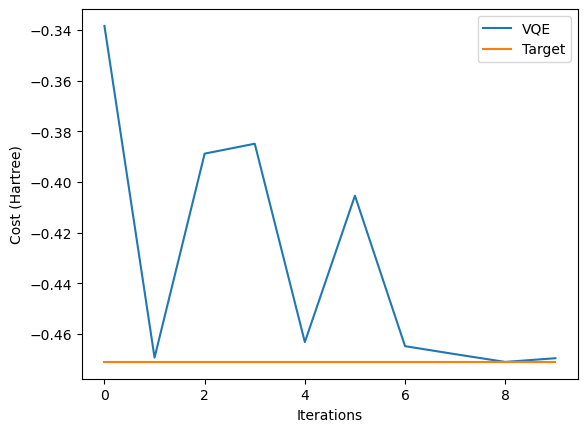

In [14]:
fig, ax = plt.subplots()
x = np.linspace(0, 10, 10)

# Define the constant function
y_constant = np.full_like(x, h)
ax.plot(
    range(cost_history_dict["iters"]), cost_history_dict["cost_history"], label="VQE"
)
ax.set_xlabel("Iterations")
ax.set_ylabel("Cost (Hartree)")
ax.plot(y_constant, label="Target")
plt.legend()
plt.draw()

In [15]:
h2_hamiltonian = SparsePauliOp.from_list(
    [("I", -1.04886087), ("Z", -0.7967368), ("X", 0.18121804)]
)

# exact ground state energy of hamiltonian
nuclear_repulsion = 0.71997
A = np.array(h2_hamiltonian)
eigenvalues, eigenvectors = np.linalg.eig(A)
print("Electronic ground state energy (Hartree): ", min(eigenvalues).real)
print("Nuclear repulsion energy (Hartree): ", nuclear_repulsion)
print(
    "Total ground state energy (Hartree): ", min(eigenvalues).real + nuclear_repulsion
)
h2 = min(eigenvalues).real + nuclear_repulsion

Electronic ground state energy (Hartree):  -1.8659468547627318
Nuclear repulsion energy (Hartree):  0.71997
Total ground state energy (Hartree):  -1.1459768547627318


In [16]:
h2_hamiltonian_isa = h2_hamiltonian.apply_layout(layout=ansatz.layout)

In [17]:
x0 = [2, 0, 0]

In [18]:
# QPU time 4min for ibm_brisbane
batch = Batch(backend=backend)

cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}
estimator = Estimator(mode=batch)
estimator.options.default_shots = 10000

res = minimize(
    cost_func,
    x0,
    args=(ansatz, h2_hamiltonian_isa, estimator),
    method="cobyla",
    options={"maxiter": 15},
)

batch.close()

Iters. done: 1 [Current cost: -0.722713690264]
Iters. done: 2 [Current cost: -0.2630196724959999]
Iters. done: 3 [Current cost: -0.2618523792879999]
Iters. done: 4 [Current cost: -0.580438771064]
Iters. done: 5 [Current cost: -1.716408727312]
Iters. done: 6 [Current cost: -0.6675901411759999]
Iters. done: 7 [Current cost: -1.593830494208]
Iters. done: 8 [Current cost: -1.8554239384400002]
Iters. done: 9 [Current cost: -1.7580500084000001]
Iters. done: 10 [Current cost: -1.861192328976]
Iters. done: 11 [Current cost: -1.804847784104]
Iters. done: 12 [Current cost: -1.866299591664]
Iters. done: 13 [Current cost: -1.86377252716]
Iters. done: 14 [Current cost: -1.8619066441839998]
Iters. done: 15 [Current cost: -1.8656440669999999]


In [19]:
h2_vqe = res.fun + nuclear_repulsion
print(
    "The reference ground state energy is ", min(eigenvalues).real + nuclear_repulsion
)
print("The computed ground state energy is ", h2_vqe)

The reference ground state energy is  -1.1459768547627318
The computed ground state energy is  -1.146329591664


/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/numeric.py:476: ComplexWarning: Casting complex values to real discards the imaginary part
  multiarray.copyto(res, fill_value, casting='unsafe')


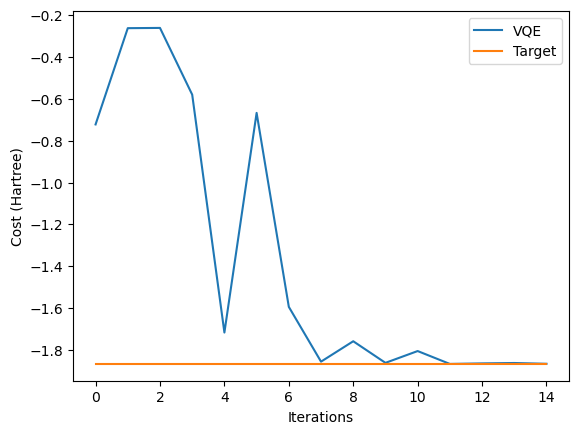

In [20]:
fig, ax = plt.subplots()
x = np.linspace(0, 5, 15)

# Define the constant function
y_constant = np.full_like(x, min(eigenvalues))
ax.plot(
    range(cost_history_dict["iters"]), cost_history_dict["cost_history"], label="VQE"
)
ax.set_xlabel("Iterations")
ax.set_ylabel("Cost (Hartree)")
ax.plot(y_constant, label="Target")
plt.legend()
plt.draw()

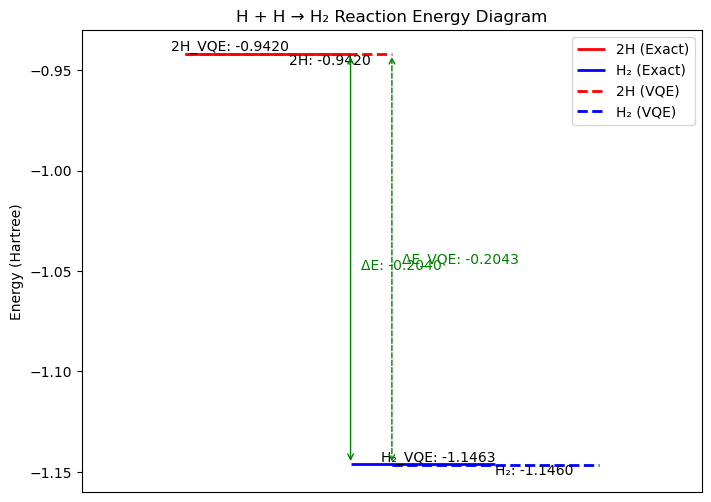

In [21]:
# Theoretical values
E_H_theo = h.real
E_H2_theo = h2

# Experimental values
E_H_exp = h_vqe
E_H2_exp = h2_vqe

# Calculate reaction energies
E_reaction_theo = E_H2_theo - (2 * E_H_theo)
E_reaction_exp = E_H2_exp - (2 * E_H_exp)

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(0, 3)
ax.set_ylim(-1.16, -0.93)  # Adjust y-axis range to highlight differences
ax.set_xticks([])
ax.set_ylabel("Energy (Hartree)")
ax.set_title("H + H → H₂ Reaction Energy Diagram")

# Plot theoretical energy levels
ax.hlines(
    y=2 * E_H_theo, xmin=0.5, xmax=1.3, linewidth=2, color="r", label="2H (Exact)"
)
ax.hlines(y=E_H2_theo, xmin=1.3, xmax=2, linewidth=2, color="b", label="H₂ (Exact)")

# Plot experimental energy levels
ax.hlines(
    y=2 * E_H_exp,
    xmin=0.5,
    xmax=1.5,
    linewidth=2,
    color="r",
    linestyle="dashed",
    label="2H (VQE)",
)
ax.hlines(
    y=E_H2_exp,
    xmin=1.5,
    xmax=2.5,
    linewidth=2,
    color="b",
    linestyle="dashed",
    label="H₂ (VQE)",
)

# Add labels
ax.text(
    1,
    2 * E_H_theo,
    f"2H: {2*E_H_theo:.4f}",
    verticalalignment="top",
    horizontalalignment="left",
)
ax.text(
    2,
    E_H2_theo,
    f"H₂: {E_H2_theo:.4f}",
    verticalalignment="top",
    horizontalalignment="left",
)
ax.text(
    1,
    2 * E_H_exp,
    f"2H_VQE: {2*E_H_exp:.4f}",
    verticalalignment="bottom",
    horizontalalignment="right",
)
ax.text(
    2,
    E_H2_exp,
    f"H₂_VQE: {E_H2_exp:.4f}",
    verticalalignment="bottom",
    horizontalalignment="right",
)

# Add arrows for reaction energy with ΔE label in the middle
mid_y_theo = (2 * E_H_theo + E_H2_theo) / 2
mid_y_exp = (2 * E_H_exp + E_H2_exp) / 2
ax.annotate(
    "",
    xy=(1.3, E_H2_theo),
    xytext=(1.3, 2 * E_H_theo),
    arrowprops=dict(arrowstyle="<->", color="g"),
)
ax.text(
    1.35, mid_y_theo, f"ΔE: {E_reaction_theo:.4f}", color="g", verticalalignment="top"
)

ax.annotate(
    "",
    xy=(1.5, E_H2_exp),
    xytext=(1.5, 2 * E_H_exp),
    arrowprops=dict(arrowstyle="<->", color="g", linestyle="dashed"),
)
ax.text(
    1.55,
    mid_y_exp,
    f"ΔE_VQE: {E_reaction_exp:.4f}",
    color="g",
    verticalalignment="center",
)

# Add legend
ax.legend()

plt.show()